# [Reranker](https://devocean.sk.com/blog/techBoardDetail.do?ID=167335&boardType=techBlog)
- Reranker(리랭커)는 현대적인 두 단계 검색 시스템(Two-Stage Retrieval System)에서 사용되는 핵심 컴포넌트입니다. 대규모 데이터셋에서 효율적이고 정확한 검색을 수행하기 위해 설계되었으며, 주로 첫 번째 단계인 Retriever가 찾아낸 문서들의 순위를 재조정하는 역할을 합니다.

## [Reranker가 필요한 이유](https://aws.amazon.com/ko/blogs/tech/korean-reranker-rag/)

먼저 현재 RAG의 문제점에 대해서 살펴보도록 하겠습니다. RAG는 수많은 텍스트 문서에서 의미론적 검색 (Semantic search) 과정을 수행합니다. 의미론적 검색에는 일반적으로 벡터 검색을 활용 되는데, 이 과정에서 두 가지 정보 손실이 발생하게 됩니다.
- `첫 번째는 문서의 임베딩 벡터 변환 과정에서의 손실입니다.` 임베딩 벡터 변환이란 문서를 n개의 숫자로 재 표현하는 것을 의미하는데, 정보의 손실은 문서가 긴 경우에 정해진 벡터의 차원으로 표현하기 어려울 때 발생하게 됩니다.
- `두 번째는 검색 과정에서의 손실입니다.` RAG는 검색 시간 단축을 위해 Approximate Nearnest Neighbor search (ANNs) 기술을 활용합니다. 이 방법은 질문과 문서 사이의 관련성 체크 횟수를 현저히 줄임으로써 검색속도를 높일 수 있습니다. 하지만 이 과정에서 발생하는 관련성 정확도 하락이 정보의 손실로 나타나게 됩니다. 이러한 정보 손실로 인해 LLM으로 전달되는 컨텍스트의 상위 k개 이내에서 질문에 대한 관련 정보가 누락되는 경우가 발생합니다.

- 이러한 문제는 검색 후 반환되는 문서수를 늘림 (k 증가) 으로써 간단히 해결할 수 있습니다. 하지만 이 방법은 LLM에 전달하는 컨텍스트가 늘어나기 때문에 비용 효율적이지 않습니다.
- 그 뿐만이 아닙니다. 최근 출판된 논문에 따르면 RAG의 정확도는 관련정보의 컨텍스트 내 존재 유무가 아닌, 순서라는 것을 발견하였습니다.

즉, 관련 정보가 컨텍스트 내 상위권에 위치하고 있을 때 좋은 답변을 얻을 수 있다는 뜻 입니다.

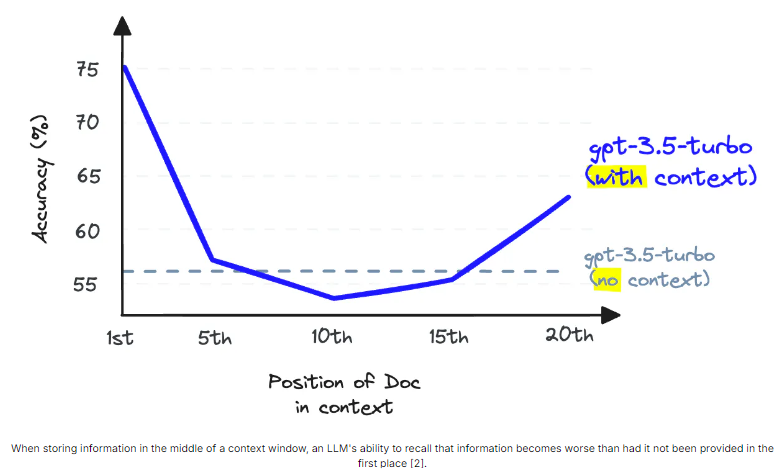

## [Power of Rerankers](https://www.pinecone.io/learn/series/rag/rerankers/)
- 기존에 벡터 검색을 위해 사용하는 구조가 `Bi-encoder`라면, `rerank`를 위한 구조는 `Cross-encoder`입니다.
- `Bi-encoder`는 질의와 정보를 각각 임베딩한 후 유사도를 계산합니다.
- `Cross-encoder`는 질의와 정보를 입력으로 사용하여 유사도를 출력합니다. 질의와 정보를 각각 입력하고 유사도를 얻는 `Bi-encoder`와 다르게 질의와 정보의 내용을 한번에 고려하기 때문에 더욱 정확한 유사도를 얻을 수 있다고 합니다. 이 유사도를 사용하여 질의와의 관련성에 따라 정보(문서)를 재정렬합니다.
- 하지만 `Cross-encoder`는 모든 조합들을 활용해 인풋으로 활용해야 하기 때문에, 비용이 높습니다. 때문에 일반적인 벡터 검색(`retrieval`)을 진행한 후, `reranker` 기반으로 순위를 재정렬하는 경우가 일반적입니다.


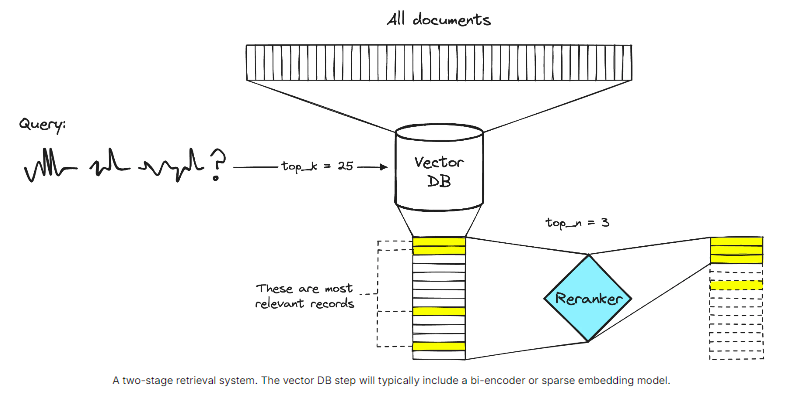

### Bi-encoder

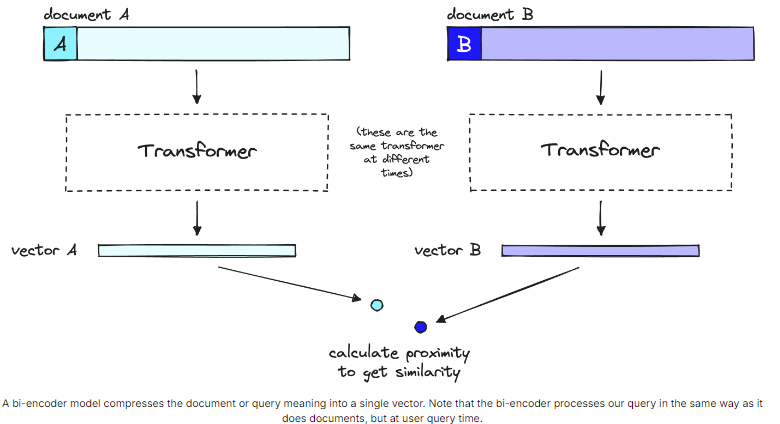

### Cross-encoder

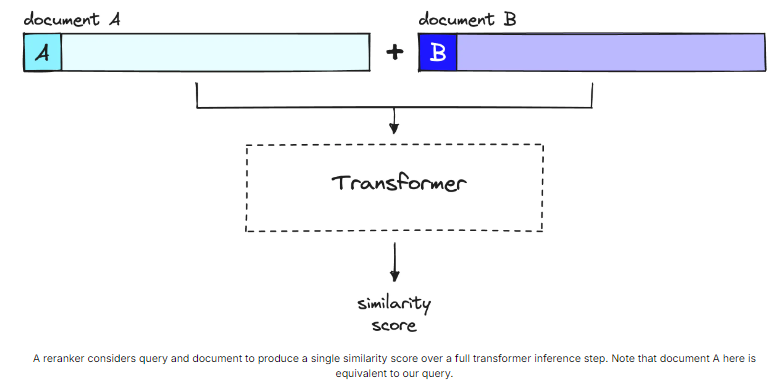

## Reranker 장단점

- 장점
  - 검색 정확도 크게 향상
  - 복잡한 의미적 관계 모델링 가능
  - 첫 단계 검색의 한계 보완
- 단점
  - 계산 비용 증가
  - 처리 시간 증가
  - 대규모 데이터셋에 직접 적용 어려움

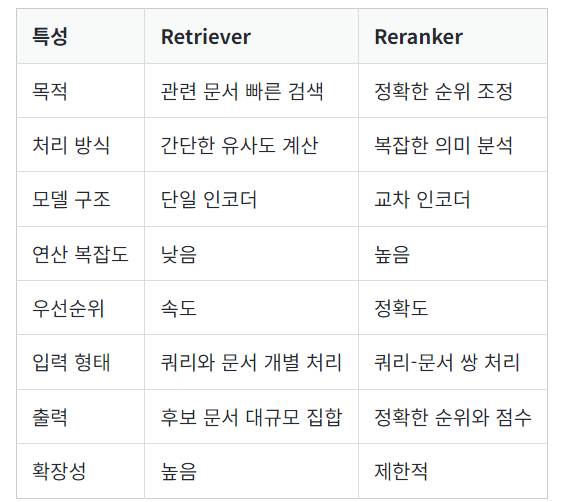

# Reranker 예제
- Cross encoder reranker는 검색 증강 생성(RAG) 시스템의 성능을 향상시키기 위해 사용되는 기술입니다. 이 문서는 Hugging Face의 cross encoder 모델을 사용하여 retriever에서 reranker를 구현하는 방법을 설명합니다.

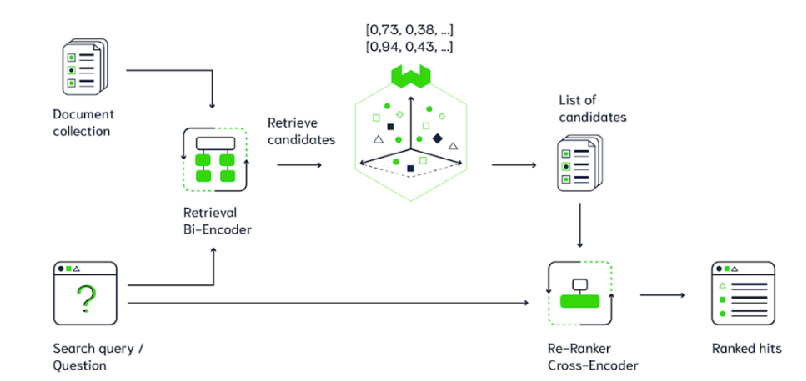

## Vector DB

- 임베딩 모델 설정

In [1]:
from langchain_ollama import OllamaEmbeddings

embeddings = OllamaEmbeddings(model="qwen3-embedding:0.6b")

- vectorstore 로드

In [2]:
from langchain_community.vectorstores import Chroma

vector_db = Chroma(
    embedding_function=embeddings, # 임베딩 함수
    collection_name="rag_keywords", # 컬렉션 이름
    persist_directory="./chroma_rag_keywords" # 영구 저장 경로
)

print("Chroma VectorStore가 로드 되었습니다.")

C:\Users\Playdata\AppData\Local\Temp\ipykernel_17404\4257933221.py:3: LangChainDeprecationWarning: The class `Chroma` was deprecated in LangChain 0.2.9 and will be removed in 1.0. An updated version of the class exists in the `langchain-chroma package and should be used instead. To use it run `pip install -U `langchain-chroma` and import as `from `langchain_chroma import Chroma``.
  vector_db = Chroma(


Chroma VectorStore가 로드 되었습니다.


In [3]:
stats = vector_db._collection.count()

print(f"저장된 문서 수: {stats}")

저장된 문서 수: 30


## Bi-Encoder
- Vector DB를 이용한 유사도 결과값

- 검색기 설정

In [4]:
# 검색기 설정
retriever = vector_db.as_retriever(
    search_kwargs={"k": 10}
)

- 질의 설정

In [27]:
# 질의 설정
query = "멀티모델에 대해서 알려줘."
query

'멀티모델에 대해서 알려줘.'

- 질의 수행 및 결과 문서 반환

In [6]:
# 질의 수행 및 결과 문서 반환
docs = retriever.invoke(query)

In [7]:
len(docs)

10

- 결과 문서 출력

In [8]:
# 문서 출력 도우미 함수
def pretty_print_docs(docs):
    print(
        f"\n{'-' * 100}\n".join(
            [f"Document {i+1}:\n\n" + d.page_content for i, d in enumerate(docs)]
        )
    )

In [9]:
# 결과 문서 출력
pretty_print_docs(docs)

Document 1:

멀티모달 (Multimodal)

정의: 멀티모달은 여러 종류의 데이터 모드(예: 텍스트, 이미지, 소리 등)를 결합하여 처리하는 기술입니다. 이는 서로 다른 형식의 데이터 간의 상호 작용을 통해 보다 풍부하고 정확한 정보를 추출하거나 예측하는 데 사용됩니다.
예시: 이미지와 설명 텍스트를 함께 분석하여 더 정확한 이미지 분류를 수행하는 시스템은 멀티모달 기술의 예입니다.
연관키워드: 데이터 융합, 인공지능, 딥러닝
----------------------------------------------------------------------------------------------------
Document 2:

데이터 마이닝

정의: 데이터 마이닝은 대량의 데이터에서 유용한 정보를 발굴하는 과정입니다. 이는 통계, 머신러닝, 패턴 인식 등의 기술을 활용합니다.
예시: 소매업체가 고객 구매 데이터를 분석하여 판매 전략을 수립하는 것은 데이터 마이닝의 예입니다.
연관키워드: 빅데이터, 패턴 인식, 예측 분석

멀티모달 (Multimodal)
----------------------------------------------------------------------------------------------------
Document 3:

정의: GPT는 대규모의 데이터셋으로 사전 훈련된 생성적 언어 모델로, 다양한 텍스트 기반 작업에 활용됩니다. 이는 입력된 텍스트에 기반하여 자연스러운 언어를 생성할 수 있습니다.
예시: 사용자가 제공한 질문에 대해 자세한 답변을 생성하는 챗봇은 GPT 모델을 사용할 수 있습니다.
연관키워드: 자연어 처리, 텍스트 생성, 딥러닝

InstructGPT
----------------------------------------------------------------------------------------------------
Document 4:

InstructGPT

정의: InstructG

## Cross-Encoder

- [Reranker Model 조회](https://huggingface.co/models?sort=trending&search=reranker)

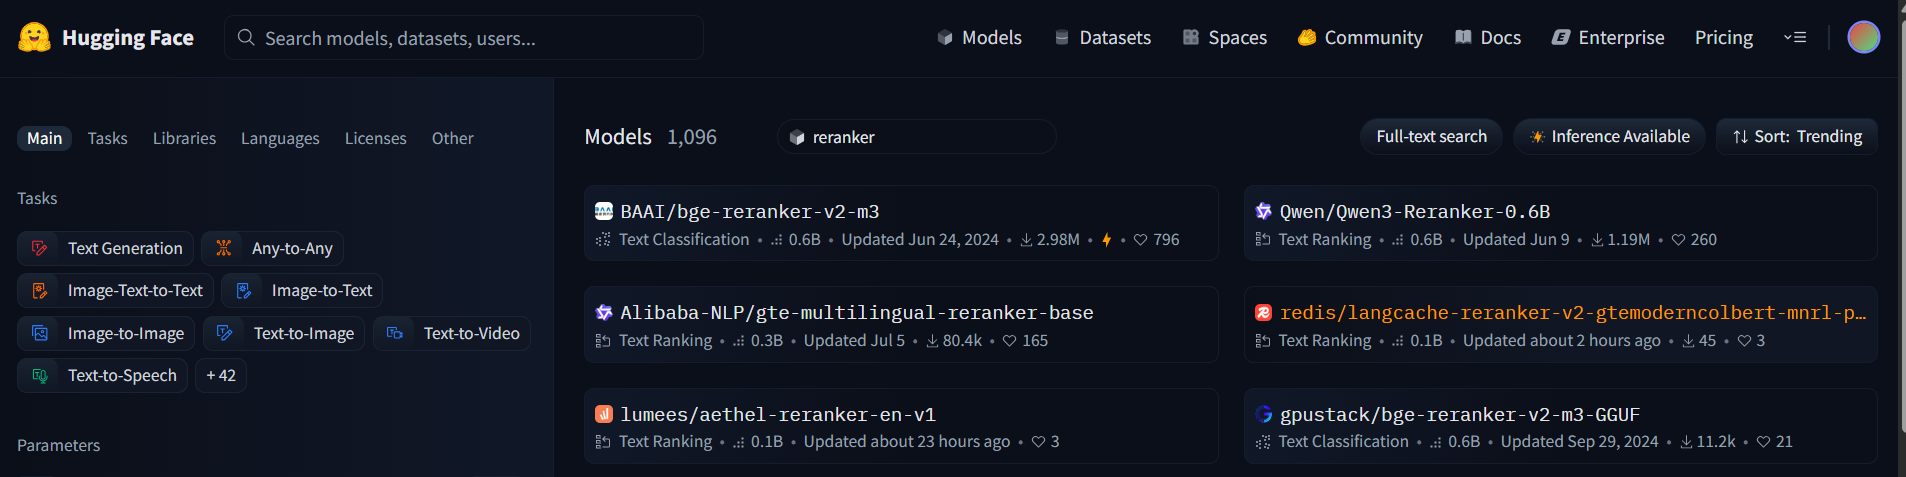

- [HuggingFace API Key](https://huggingface.co/settings/tokens)

In [10]:
from dotenv import load_dotenv

load_dotenv()


True

- CrossEncoder 생성

In [19]:
from sentence_transformers import CrossEncoder

# CrossEncoder는 문서와 쿼리의 관련성을 점수로 평가하는 모델입니다
cross_encoder = CrossEncoder(
    model_name_or_path="Qwen/Qwen3-Reranker-4B",  # 한국어 reranking 전용 모델
    max_length=512,  # 입력 텍스트의 최대 토큰 길이 (512토큰까지 처리)
    device="cpu",  # 모델을 CPU에서 실행 (GPU 사용 시 "cuda"로 변경)
    cache_folder="./models/"  # 다운로드한 모델을 저장할 로컬 폴더 경로
)

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Some weights of Qwen3ForSequenceClassification were not initialized from the model checkpoint at Qwen/Qwen3-Reranker-4B and are newly initialized: ['score.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


- Reranker 실행 

In [28]:
query

'멀티모델에 대해서 알려줘.'

In [29]:
# CrossEncoder.rank()는 num_labels=1 모델에서만 작동하므로
# predict()를 사용하여 점수를 계산하고 정렬합니다
# Qwen3-Reranker 모델은 padding token이 없어 batch_size=1로 처리해야 합니다
pairs = [[query, doc.page_content] for doc in docs]
scores = cross_encoder.predict(pairs, batch_size=1)

- 점수 순으로 정렬 (높은 점수부터)

In [30]:
# 점수 순으로 정렬 (높은 점수부터)
doc_score_pairs = sorted(zip(docs, scores), key=lambda x: x[1], reverse=True)


In [31]:
for doc, score in doc_score_pairs[:3]:
    print(f"{doc.page_content[:50]}.. / 점수: {score}")

Word2Vec

정의: Word2Vec은 단어를 벡터 공간에 매핑하여 단어 간의 의미적 .. / 점수: 0.9930033087730408
Attention 메커니즘

정의: Attention 메커니즘은 딥러닝에서 중요한 정보에 .. / 점수: 0.9853199124336243
InstructGPT

정의: InstructGPT는 사용자의 지시에 따라 특정한 작업을 .. / 점수: 0.9840520620346069


## Bi-encoder vs Cross-encoder 비교 테스트

Cross-encoder 강의용 벡터 DB를 사용하여 Bi-encoder(기본 Retriever)와 Cross-encoder의 성능을 비교합니다.


### Cross-encoder 테스트용 쿼리 예시

다음 쿼리들은 Cross-encoder의 장점을 보여주기 위해 설계되었습니다:
- **의미적 유사성 테스트**: "머신러닝 모델을 학습시키는 방법" → "머신러닝 모델 학습", "딥러닝 알고리즘 훈련", "AI 시스템 교육" 모두 관련
- **동의어 테스트**: "벡터 데이터베이스" → "임베딩 저장 시스템", "의미 기반 검색 인덱스" 관련
- **문맥 이해 테스트**: "텍스트를 숫자로 변환하는 기술" → "텍스트 임베딩", "문장 벡터 표현" 관련

In [32]:
# Cross-encoder 강의용 테스트 쿼리
test_queries = [
    "머신러닝 모델을 학습시키는 방법",  # 의미적으로 유사하지만 표현이 다른 문서들과 매칭
    "텍스트를 숫자 벡터로 변환하는 기술",  # 동의어/유사 표현 테스트
    "웹에서 데이터를 자동으로 수집하는 방법",  # 문맥 이해 테스트
    "데이터베이스에서 정보를 찾는 명령어",  # 의미 기반 검색 테스트
    "문서에 설명을 추가하는 작업"  # 유사 개념 매칭 테스트
]

print("Cross-encoder 테스트용 쿼리:")
for i, query in enumerate(test_queries, 1):
    print(f"{i}. {query}")


Cross-encoder 테스트용 쿼리:
1. 머신러닝 모델을 학습시키는 방법
2. 텍스트를 숫자 벡터로 변환하는 기술
3. 웹에서 데이터를 자동으로 수집하는 방법
4. 데이터베이스에서 정보를 찾는 명령어
5. 문서에 설명을 추가하는 작업


In [33]:
def compare_bi_vs_cross_encoder(query, vectorstore, cross_encoder, k=10, top_n=3):
    """
    Bi-encoder와 Cross-encoder의 검색 결과를 비교하는 함수
    """
    print("=" * 80)
    print(f"쿼리: {query}")
    print("=" * 80)
    
    # 1. Bi-encoder 검색 (기본 Retriever)
    print("\n[Bi-encoder 결과]")
    print("-" * 80)
    bi_docs = vectorstore.similarity_search(query, k=k)
    print(f"검색된 문서 수: {len(bi_docs)}")
    print(f"\n상위 {top_n}개 문서:")
    for i, doc in enumerate(bi_docs[:top_n], 1):
        print(f"\n{i}. {doc.page_content[:200]}...")
    
    # 2. Cross-encoder Reranking
    print("\n\n[Cross-encoder Reranking 결과]")
    print("-" * 80)
    pairs = [[query, doc.page_content] for doc in bi_docs]
    scores = cross_encoder.predict(pairs, batch_size=1)
    
    # 점수 순으로 정렬
    doc_score_pairs = sorted(zip(bi_docs, scores), key=lambda x: x[1], reverse=True)
    reranked_docs = [doc for doc, score in doc_score_pairs[:top_n]]
    
    print(f"Reranking된 상위 {top_n}개 문서:")
    for i, (doc, score) in enumerate(doc_score_pairs[:top_n], 1):
        print(f"\n{i}. [점수: {score:.4f}] {doc.page_content[:200]}...")
    
    # 3. 순위 변화 확인
    print("\n\n[순위 변화 분석]")
    print("-" * 80)
    bi_top3_ids = [id(doc) for doc in bi_docs[:top_n]]
    reranked_top3_ids = [id(doc) for doc in reranked_docs]
    
    print(f"Bi-encoder 상위 {top_n}개 문서 ID: {[id(doc) for doc in bi_docs[:top_n]]}")
    print(f"Cross-encoder 상위 {top_n}개 문서 ID: {reranked_top3_ids}")
    
    if bi_top3_ids != reranked_top3_ids:
        print("\nCross-encoder가 순위를 재조정했습니다!")
        print("  → 의미적 관련성을 더 정확히 파악하여 더 관련성 높은 문서를 상위에 배치했습니다.")
    else:
        print("\n→ 두 방법의 결과가 동일합니다.")
    
    return bi_docs[:top_n], reranked_docs


In [26]:
# 테스트 쿼리로 비교 실행
test_query = test_queries[0]  # "머신러닝 모델을 학습시키는 방법"

bi_results, cross_results = compare_bi_vs_cross_encoder(
    query=test_query,
    vectorstore=vector_db,
    cross_encoder=cross_encoder,
    k=10,
    top_n=2
)


쿼리: 머신러닝 모델을 학습시키는 방법

[Bi-encoder 결과]
--------------------------------------------------------------------------------
검색된 문서 수: 10

상위 2개 문서:

1. InstructGPT

정의: InstructGPT는 사용자의 지시에 따라 특정한 작업을 수행하기 위해 최적화된 GPT 모델입니다. 이 모델은 보다 정확하고 관련성 높은 결과를 생성하도록 설계되었습니다.
예시: 사용자가 "이메일 초안 작성"과 같은 특정 지시를 제공하면, InstructGPT는 관련 내용을 기반으로 이메일을 작성합니다.
연관키워드: 인공지능...

2. Deep Learning

정의: 딥러닝은 인공신경망을 이용하여 복잡한 문제를 해결하는 머신러닝의 한 분야입니다. 이는 데이터에서 고수준의 표현을 학습하는 데 중점을 둡니다.
예시: 이미지 인식, 음성 인식, 자연어 처리 등에서 딥러닝 모델이 활용됩니다.
연관키워드: 인공신경망, 머신러닝, 데이터 분석

Schema...


[Cross-encoder Reranking 결과]
--------------------------------------------------------------------------------
Reranking된 상위 2개 문서:

1. [점수: 0.9903] InstructGPT

정의: InstructGPT는 사용자의 지시에 따라 특정한 작업을 수행하기 위해 최적화된 GPT 모델입니다. 이 모델은 보다 정확하고 관련성 높은 결과를 생성하도록 설계되었습니다.
예시: 사용자가 "이메일 초안 작성"과 같은 특정 지시를 제공하면, InstructGPT는 관련 내용을 기반으로 이메일을 작성합니다.
연관키워드: 인공지능...

2. [점수: 0.9831] Deep Learning

정의: 딥러닝은 인공신경망을 이용하여 복잡한 문제를 해결하는 머신러닝의 한 분야입니다. 이는 데이터에서 고수준의 표현을 학습하는 데 중점을

### 모든 테스트 쿼리로 비교 실행

여러 쿼리에 대해 Bi-encoder와 Cross-encoder의 성능을 비교합니다.


In [34]:
# 모든 테스트 쿼리에 대해 비교 실행
for query in test_queries:
    print("\n\n")
    compare_bi_vs_cross_encoder(
        query=query,
        vectorstore=vector_db,
        cross_encoder=cross_encoder,
        k=10,
        top_n=2
    )
    print("\n" + "="*80 + "\n")





쿼리: 머신러닝 모델을 학습시키는 방법

[Bi-encoder 결과]
--------------------------------------------------------------------------------
검색된 문서 수: 10

상위 2개 문서:

1. InstructGPT

정의: InstructGPT는 사용자의 지시에 따라 특정한 작업을 수행하기 위해 최적화된 GPT 모델입니다. 이 모델은 보다 정확하고 관련성 높은 결과를 생성하도록 설계되었습니다.
예시: 사용자가 "이메일 초안 작성"과 같은 특정 지시를 제공하면, InstructGPT는 관련 내용을 기반으로 이메일을 작성합니다.
연관키워드: 인공지능...

2. Deep Learning

정의: 딥러닝은 인공신경망을 이용하여 복잡한 문제를 해결하는 머신러닝의 한 분야입니다. 이는 데이터에서 고수준의 표현을 학습하는 데 중점을 둡니다.
예시: 이미지 인식, 음성 인식, 자연어 처리 등에서 딥러닝 모델이 활용됩니다.
연관키워드: 인공신경망, 머신러닝, 데이터 분석

Schema...


[Cross-encoder Reranking 결과]
--------------------------------------------------------------------------------
Reranking된 상위 2개 문서:

1. [점수: 0.9903] InstructGPT

정의: InstructGPT는 사용자의 지시에 따라 특정한 작업을 수행하기 위해 최적화된 GPT 모델입니다. 이 모델은 보다 정확하고 관련성 높은 결과를 생성하도록 설계되었습니다.
예시: 사용자가 "이메일 초안 작성"과 같은 특정 지시를 제공하면, InstructGPT는 관련 내용을 기반으로 이메일을 작성합니다.
연관키워드: 인공지능...

2. [점수: 0.9831] Deep Learning

정의: 딥러닝은 인공신경망을 이용하여 복잡한 문제를 해결하는 머신러닝의 한 분야입니다. 이는 데이터에서 고수준의 표현을 학습하는 데 

## RAG with Reranking 예제 

### LLM
- [OpenAI Key 발급](https://platform.openai.com/api-keys)
- [OpenAI 요금](https://openai.com/api/pricing/)

In [35]:
from langchain_openai import ChatOpenAI

llm = ChatOpenAI(
    model="gpt-5-nano",
    reasoning_effort="high",        # 논리성 강화
)

### qa_with_reranking

In [ ]:
def qa_with_reranking(query, vectorstore, cross_encoder, llm, k=10, top_n=3):
    """
    CrossEncoder를 사용한 QA 함수
    """
    # 1. 초기 검색
    docs = vectorstore.similarity_search(query, k=k)
    
    # 2. Reranking
    pairs = [[query, doc.page_content] for doc in docs]
    # Qwen3-Reranker 모델은 padding token이 없어 batch_size=1로 처리해야 합니다
    scores = cross_encoder.predict(pairs, batch_size=1)
    
    # 3. 점수 순으로 정렬
    doc_score_pairs = sorted(zip(docs, scores), key=lambda x: x[1], reverse=True)
    top_docs = [doc for doc, score in doc_score_pairs[:top_n]]
    
    # 4. 문서 내용 합치기
    context = "\n\n".join([doc.page_content for doc in top_docs])
    
    # 5. 프롬프트 생성
    prompt = f"""
    다음 문맥을 참고하여 질문에 답하세요.

    문맥:
    {context}

    질문: {query}

    답변:"""
    
    # 6. LLM 호출
    response = llm.invoke(prompt)
    
    return {
        "answer": response.content,
        "doc_scores": doc_score_pairs[:top_n]
    }

In [43]:
# 사용 예시
result = qa_with_reranking(
    query="벡터 데이터베이스의 역할은 무엇인가요?",
    vectorstore=vector_db,
    cross_encoder=cross_encoder,
    llm=llm,
    k=10,
    top_n=3
)

In [44]:
print(result["answer"])

벡터 데이터베이스(VectorStore)의 역할은 임베딩 벡터를 저장하고 관리하며, 벡터 간의 유사도에 기반한 검색을 빠르게 수행하게 하는 시스템입니다.

주요 기능
- 벡터 저장 및 메타데이터 관리: 문서나 문장 등의 임베딩 벡터와 함께 출처나 날짜 같은 메타데이터를 저장합니다.
- 근사 최근접 이웃 검색 인덱스: 질의 벡터와 저장 벡터 간의 유사도를 계산해 상위-k를 빠르게 반환합니다(주로 HNSW 등 인덱스 사용).
- 업데이트 및 관리: 벡터 추가/삭제/수정 및 인덱스 재구성 등을 지원합니다.
- 필터링/정렬: 메타데이터를 이용한 결과 필터링이 가능합니다.
- 활용 용도: 의미 기반 검색(semantic search), 질의 응답 시스템, 지식 기반 검색, 추천 등.
- 연동: 임베딩 생성 모델(예: Word2Vec, BERT 등)과 함께 사용되며, 대형 언어 모델(Large Language Model)과 결합해 RAG(정보 재검색 기반 생성) 등에 활용됩니다.

간단한 예: 질의 벡터를 생성한 후 벡터 데이터베이스에서 가장 유사한 문서 벡터를 찾아 그 문서 내용을 바탕으로 응답을 구성합니다.


In [48]:
for doc, score in result['doc_scores']:
    print("="*50)
    print(f"score: {score} / doc: {doc.page_content[:50]}")

score: 0.9902938604354858 / doc: Embedding

정의: 임베딩은 단어나 문장 같은 텍스트 데이터를 저차원의 연속적인 벡
score: 0.9902183413505554 / doc: Word2Vec

정의: Word2Vec은 단어를 벡터 공간에 매핑하여 단어 간의 의미적 
score: 0.9891884922981262 / doc: Tokenizer

정의: 토크나이저는 텍스트 데이터를 토큰으로 분할하는 도구입니다. 이는
